### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Short / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: E/P and P/B
10. Universe size over time
11. Portfolio breadth over time
12. Long vs short composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/ff3_full_price_available_universe_no_fmp_v2"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

# optional
try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
# parse dates
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (311, 4)
asset_returns: (230847, 11)
weights_at_E: (230847, 19)
signals_at_T: (577859, 15)
portfolio_membership_at_T: (230847, 18)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
ls_monthly = (
    asset_returns
    .groupby(["signal_date", "execution_date", "next_execution_date", "side"], as_index=False)["weighted_return"]
    .sum()
    .pivot(
        index=["signal_date", "execution_date", "next_execution_date"],
        columns="side",
        values="weighted_return"
    )
    .reset_index()
)

ls_monthly.columns.name = None

for col in ["long", "short"]:
    if col not in ls_monthly.columns:
        ls_monthly[col] = 0.0

ls_monthly = ls_monthly.rename(columns={
    "long": "long_return",
    "short": "short_return"
})

ls_monthly["portfolio_return_rebuilt"] = (
    ls_monthly["long_return"] + ls_monthly["short_return"]
)

ls_monthly.head()

,signal_date,execution_date,next_execution_date,long_return,short_return,portfolio_return_rebuilt
0,2000-01-31,2000-02-01,2000-03-01,-0.015362,-0.125417,-0.140779
1,2000-02-29,2000-03-01,2000-04-03,0.034549,0.043340,0.077889
2,2000-03-31,2000-04-03,2000-05-01,0.003064,0.019242,0.022306
3,2000-04-28,2000-05-01,2000-06-01,-0.007113,0.020979,0.013866
4,2000-05-31,2000-06-01,2000-07-03,0.008781,-0.043553,-0.034772


In [8]:
# optional consistency check against saved portfolio_returns.csv
check = portfolio_returns.merge(
    ls_monthly,
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["portfolio_return_rebuilt"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 1.2663481374630692e-14
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_leg": performance_summary(ls_monthly["long_return"]),
    "short_leg": performance_summary(ls_monthly["short_return"]),
    "net_portfolio": performance_summary(ls_monthly["portfolio_return_rebuilt"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_leg,0.006295,0.028848,0.755924,0.623794,-0.314361
short_leg,-0.002983,0.032072,-0.322238,0.414791,-0.762217
net_portfolio,0.003312,0.020545,0.558382,0.556270,-0.261383


### 5. Cumulative performance plot: Long / Short / Net

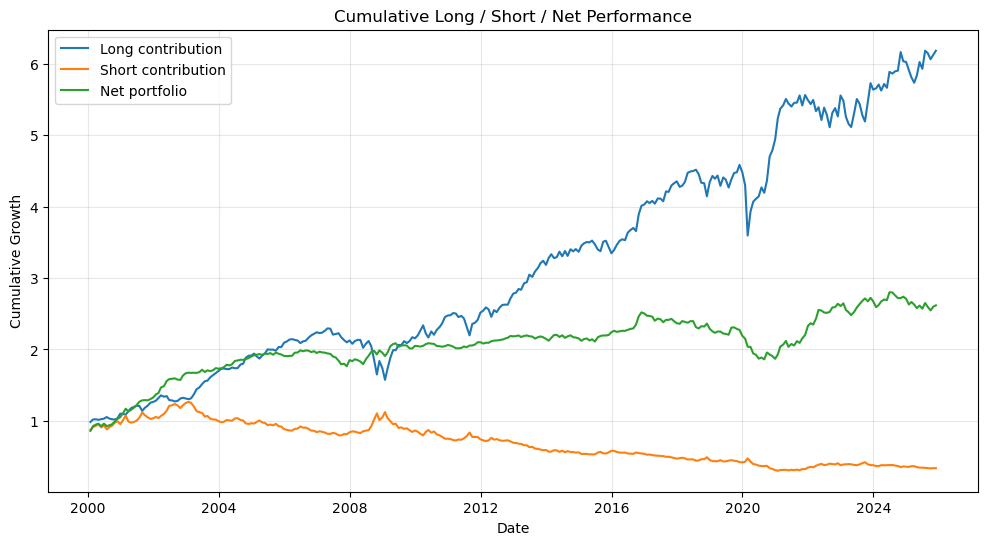

In [10]:
plot_df = ls_monthly.sort_values("signal_date").copy()

plot_df["cum_long"] = (1 + plot_df["long_return"]).cumprod()
plot_df["cum_short"] = (1 + plot_df["short_return"]).cumprod()
plot_df["cum_net"] = (1 + plot_df["portfolio_return_rebuilt"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_long"], label="Long contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_short"], label="Short contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_net"], label="Net portfolio")
plt.title("Cumulative Long / Short / Net Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

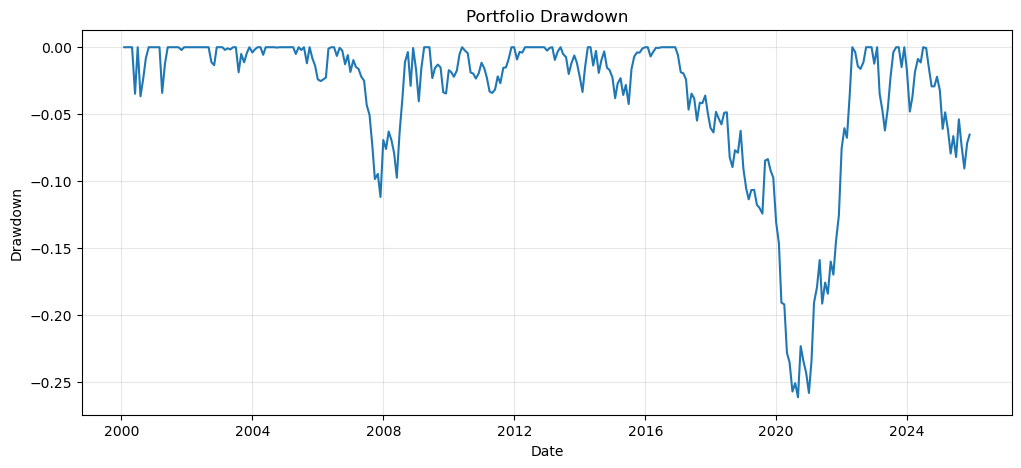

In [11]:
drawdown_df = plot_df[["signal_date", "portfolio_return_rebuilt"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["portfolio_return_rebuilt"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

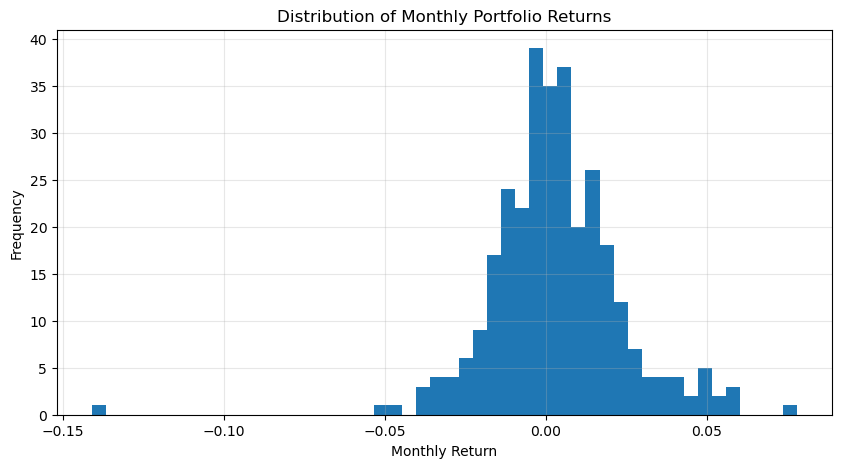

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(ls_monthly["portfolio_return_rebuilt"], bins=50)
plt.title("Distribution of Monthly Portfolio Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
corr_ls = ls_monthly["long_return"].corr(ls_monthly["short_return"])
print("Correlation between long and short contributions:", corr_ls)

Correlation between long and short contributions: -0.7774998353901252


In [14]:
ls_monthly[["long_return", "short_return", "portfolio_return_rebuilt"]].describe()

,long_return,short_return,portfolio_return_rebuilt
count,311.000000,311.000000,311.000000
mean,0.006295,-0.002983,0.003312
std,0.028848,0.032072,0.020545
min,-0.163464,-0.125417,-0.140779
25%,-0.008948,-0.021293,-0.007811
50%,0.007315,-0.004519,0.002604
75%,0.022173,0.015997,0.013926
max,0.114387,0.111620,0.077889


In [15]:
# gross-normalized leg returns assuming 0.5 gross long / 0.5 gross short
ls_monthly["long_book_raw_return"] = ls_monthly["long_return"] / 0.5
ls_monthly["short_book_pnl_per_gross"] = ls_monthly["short_return"] / 0.5

ls_monthly[[
    "long_return",
    "short_return",
    "long_book_raw_return",
    "short_book_pnl_per_gross"
]].describe()

,long_return,short_return,long_book_raw_return,short_book_pnl_per_gross
count,311.000000,311.000000,311.000000,311.000000
mean,0.006295,-0.002983,0.012590,-0.005967
std,0.028848,0.032072,0.057696,0.064144
min,-0.163464,-0.125417,-0.326929,-0.250833
25%,-0.008948,-0.021293,-0.017896,-0.042587
50%,0.007315,-0.004519,0.014631,-0.009038
75%,0.022173,0.015997,0.044345,0.031995
max,0.114387,0.111620,0.228775,0.223240


### 9. Signal diagnostics: E/P and P/B

In [16]:
weights_at_E["ep"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    230847.000000
mean          1.109418
std         117.556434
min       -1804.182913
1%           -0.349552
5%           -0.083111
50%           0.045170
95%           0.249437
99%           2.739481
max       32614.522438
Name: ep, dtype: float64

In [17]:
weights_at_E["pb"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    2.308470e+05
mean     1.952889e+03
std      1.937816e+05
min      4.579188e-07
1%       4.143167e-02
5%       5.231762e-01
50%      2.334966e+00
95%      5.439080e+01
99%      5.213513e+02
max      4.930604e+07
Name: pb, dtype: float64

In [18]:
weights_at_E["ep"].sort_values(ascending=False).head(10)

181945    32614.522438
183107    32456.199460
184306    32330.643563
43926       564.118655
43352       508.691650
227702      495.557110
228893      495.557110
230077      495.557110
104351      463.248616
44521       451.312562
Name: ep, dtype: float64

In [19]:
weights_at_E["pb"].sort_values(ascending=False).head(10)

160819    4.930604e+07
138168    4.324302e+07
137241    3.773980e+07
159802    2.093930e+07
158826    1.845908e+07
88807     1.755752e+07
88043     1.696346e+07
87283     1.642209e+07
85789     1.406745e+07
85053     1.257912e+07
Name: pb, dtype: float64

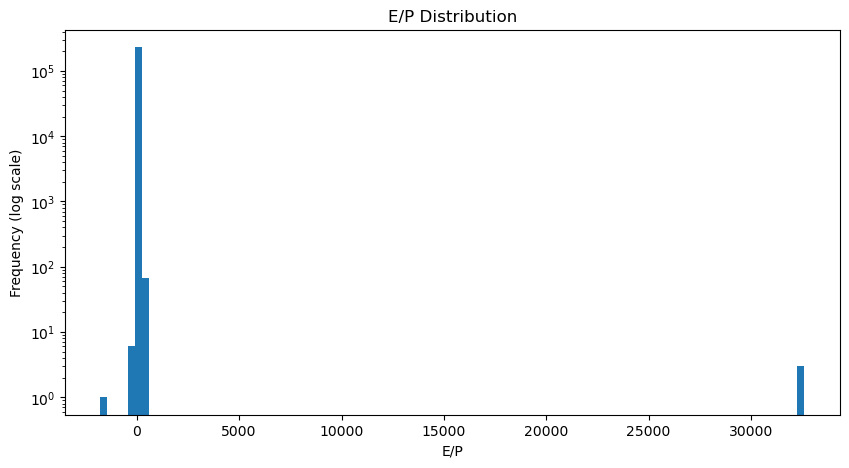

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["ep"], bins=100)
plt.yscale("log")
plt.title("E/P Distribution")
plt.xlabel("E/P")
plt.ylabel("Frequency (log scale)")
plt.show()

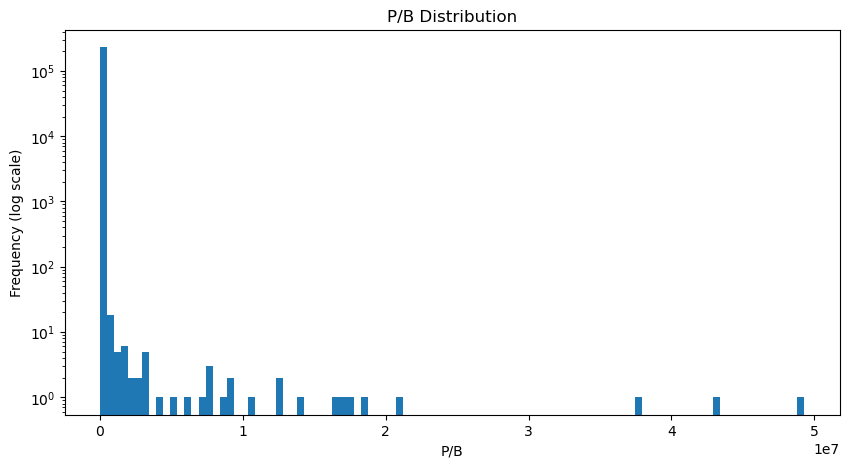

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["pb"], bins=100)
plt.yscale("log")
plt.title("P/B Distribution")
plt.xlabel("P/B")
plt.ylabel("Frequency (log scale)")
plt.show()

### 10. Universe size over time

In [22]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2000-01-31,752
1,2000-02-29,755
2,2000-03-31,790
3,2000-04-28,795
4,2000-05-31,778


In [23]:
universe_size["n_universe"].describe()

count     311.000000
mean     1858.067524
std       683.831156
min       752.000000
25%      1337.500000
50%      1675.000000
75%      2350.500000
max      3061.000000
Name: n_universe, dtype: float64

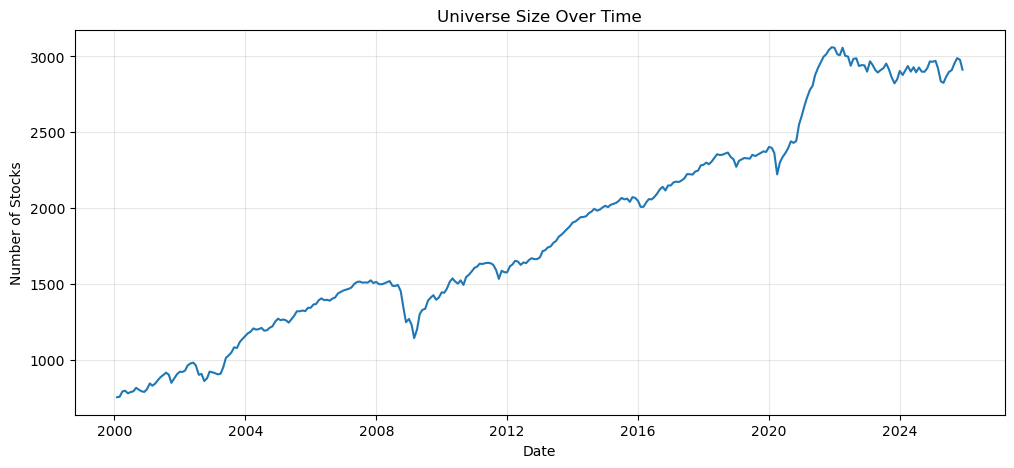

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [25]:
breadth = (
    asset_returns
    .groupby(["signal_date", "side"])["ticker"]
    .nunique()
    .unstack()
    .reset_index()
    .rename(columns={"long": "n_long", "short": "n_short"})
)

breadth.head()

side,signal_date,n_long,n_short
0,2000-01-31,150,150
1,2000-02-29,151,151
2,2000-03-31,158,158
3,2000-04-28,159,159
4,2000-05-31,155,155


In [26]:
breadth[["n_long", "n_short"]].describe()

side,n_long,n_short
count,311.000000,311.000000
mean,371.067524,371.205788
std,136.855393,136.748095
min,150.000000,150.000000
25%,267.000000,267.500000
50%,335.000000,335.000000
75%,470.000000,469.500000
max,612.000000,612.000000


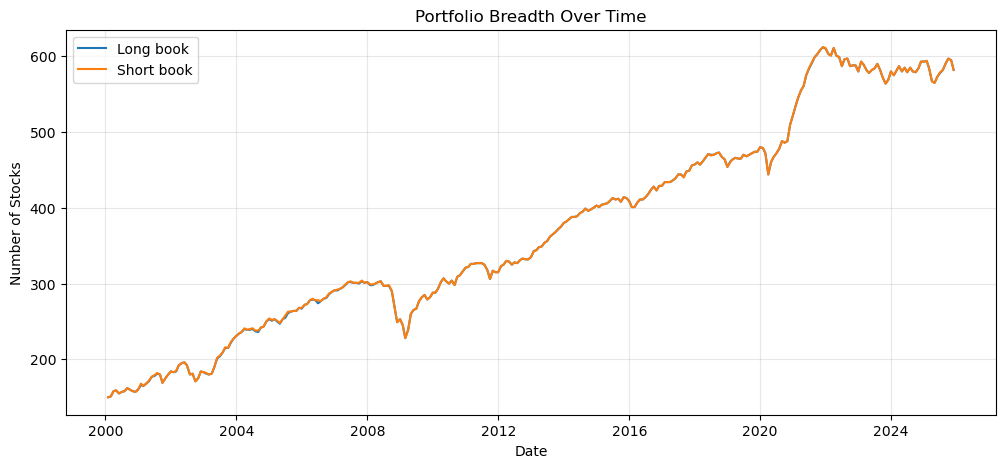

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(breadth["signal_date"], breadth["n_long"], label="Long book")
plt.plot(breadth["signal_date"], breadth["n_short"], label="Short book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long vs short composition

In [28]:
factor_summary_by_side = (
    weights_at_E.groupby("side")[["market_cap", "pb", "ep"]]
    .mean()
)

factor_summary_by_side

,market_cap,pb,ep
side,,,
long,1.432075e+09,1.148938,2.230767
short,1.438469e+11,3903.902641,-0.011513


In [29]:
factor_check = (
    weights_at_E
    .groupby(["signal_date", "side"])
    .agg({
        "market_cap": "mean",
        "pb": "mean",
        "ep": "mean"
    })
    .reset_index()
    .pivot(index="signal_date", columns="side")
)

factor_check.columns = ["_".join(col) for col in factor_check.columns]
factor_check = factor_check.reset_index()

factor_check.head()

,signal_date,market_cap_long,market_cap_short,pb_long,pb_short,ep_long,ep_short
0,2000-01-31,3.946627e+08,3.877765e+10,1.133862,72.491715,0.148276,0.011357
1,2000-02-29,4.337925e+08,3.771748e+10,1.111805,130.352385,0.157555,0.008451
2,2000-03-31,3.855670e+08,4.009856e+10,1.216649,123.716232,0.143051,0.007374
3,2000-04-28,3.852861e+08,3.854462e+10,1.189586,89.586249,0.143022,0.007996
4,2000-05-31,3.698586e+08,3.821898e+10,1.187682,70.540889,0.151882,0.008931


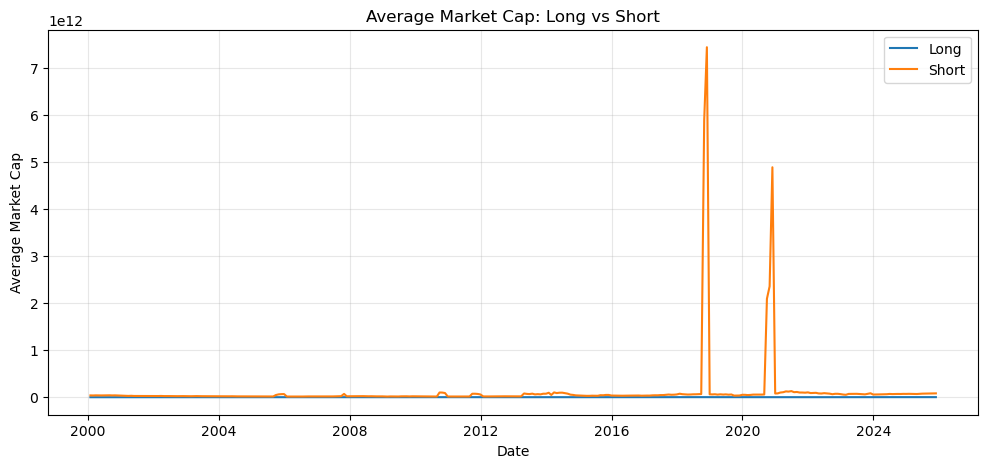

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["market_cap_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["market_cap_short"], label="Short")
plt.title("Average Market Cap: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average Market Cap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

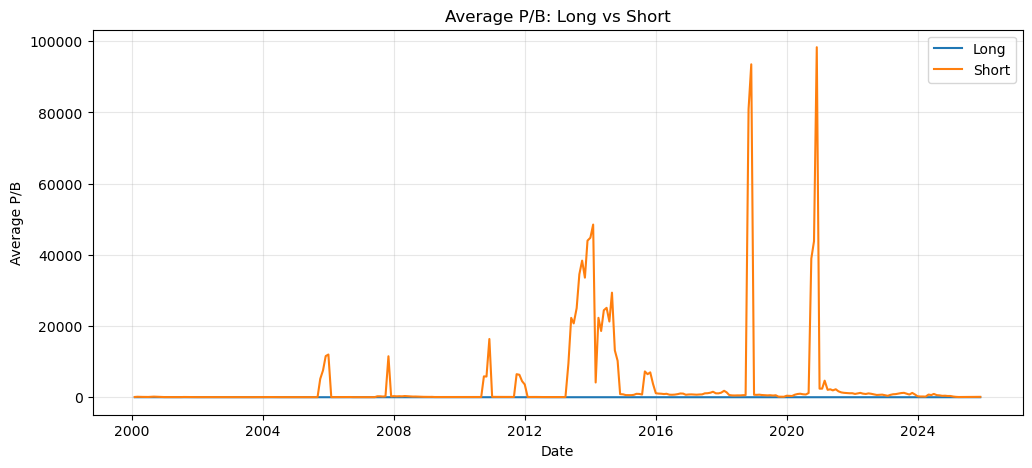

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["pb_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["pb_short"], label="Short")
plt.title("Average P/B: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average P/B")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

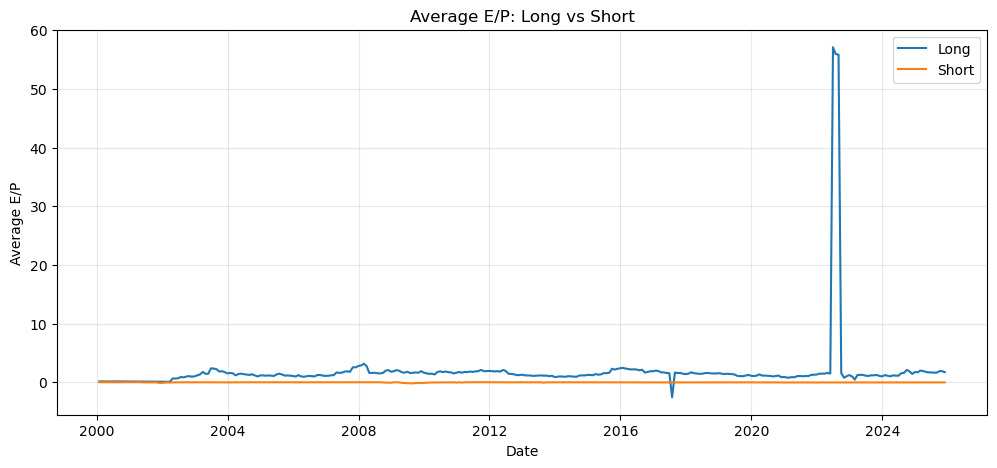

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["ep_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["ep_short"], label="Short")
plt.title("Average E/P: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average E/P")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 13. Benchmark comparison vs S&P 500

In [33]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])

sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [34]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns.head()

,signal_date,execution_date,next_execution_date,portfolio_return
0,2000-01-31,2000-02-01,2000-03-01,-0.140779
1,2000-02-29,2000-03-01,2000-04-03,0.077889
2,2000-03-31,2000-04-03,2000-05-01,0.022306
3,2000-04-28,2000-05-01,2000-06-01,0.013866
4,2000-05-31,2000-06-01,2000-07-03,-0.034772


In [35]:
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [36]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(220, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2000-01-31,2000-02-01,2000-03-01,-0.140779,-0.050904
1,2000-02-29,2000-03-01,2000-04-03,0.077889,-0.020108
2,2000-03-31,2000-04-03,2000-05-01,0.022306,0.096720
3,2000-05-31,2000-06-01,2000-07-03,-0.034772,-0.021915
4,2000-06-30,2000-07-03,2000-08-01,0.036559,0.023934


In [37]:
merged["cum_ff3"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_ff3", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_ff3,cum_sp
0,2000-01-31,-0.140779,-0.050904,0.859221,0.949096
1,2000-02-29,0.077889,-0.020108,0.926145,0.930012
2,2000-03-31,0.022306,0.096720,0.946804,1.019963
3,2000-05-31,-0.034772,-0.021915,0.913882,0.997610
4,2000-06-30,0.036559,0.023934,0.947292,1.021486


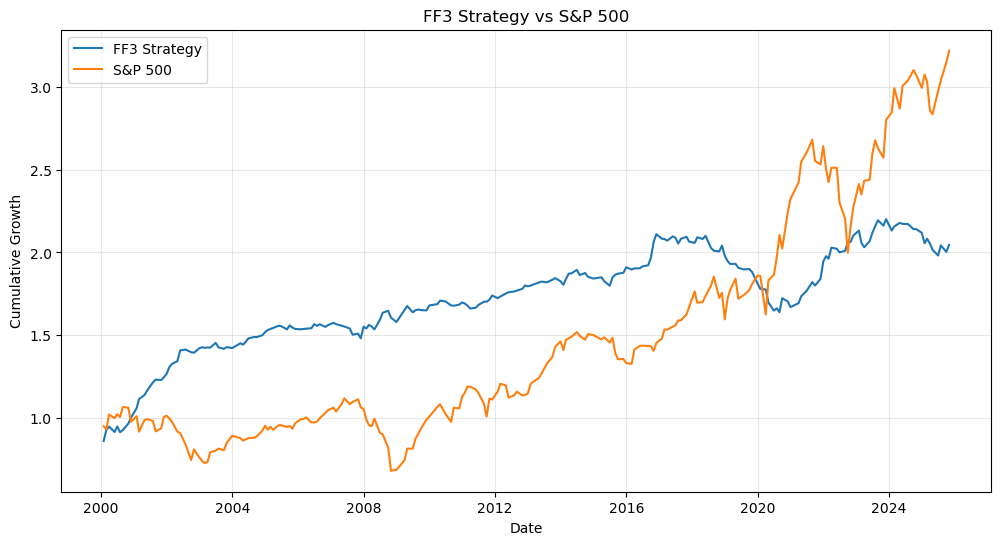

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_ff3"], label="FF3 Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("FF3 Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
def annualized_sharpe(monthly_returns):
    monthly_returns = monthly_returns.dropna()
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

print("FF3 Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

FF3 Sharpe: 0.5731129472322697
S&P 500 Sharpe: 0.49158939967173965


In [40]:
def max_drawdown(return_series):
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series):
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

benchmark_summary = pd.DataFrame({
    "FF3 Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
FF3 Strategy,0.003482,0.021044,0.573113,0.572727,-0.223434
S&P 500,0.006332,0.044619,0.491589,0.604545,-0.391858


### 14. Turnover

In [41]:
membership_sets = (
    weights_at_E.groupby("signal_date")["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values("signal_date")
    .reset_index(drop=True)
)

turnover_records = []
for i in range(1, len(membership_sets)):
    prev_set = membership_sets.loc[i - 1, "ticker_set"]
    curr_set = membership_sets.loc[i, "ticker_set"]

    entered = len(curr_set - prev_set)
    exited = len(prev_set - curr_set)
    union_n = len(curr_set | prev_set)
    prev_n = len(prev_set)

    turnover_records.append({
        "signal_date": membership_sets.loc[i, "signal_date"],
        "entered": entered,
        "exited": exited,
        "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
        "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
    })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2000-02-29,35,33,0.226667,0.797015
1,2000-03-31,58,44,0.337748,0.716667
2,2000-04-28,39,37,0.240506,0.785915
3,2000-05-31,23,31,0.169811,0.841642
4,2000-06-30,41,37,0.251613,0.777778


In [42]:
turnover_df.describe()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
count,310,310.000000,310.000000,310.000000,310.000000
mean,2013-01-13 16:34:03.870967808,70.312903,67.525806,0.197590,0.821634
min,2000-02-29 00:00:00,23.000000,28.000000,0.087102,0.658970
25%,2006-08-07 18:00:00,55.250000,50.250000,0.159422,0.797302
50%,2013-01-15 12:00:00,67.000000,63.000000,0.193728,0.824063
75%,2019-06-21 00:00:00,81.000000,79.000000,0.226263,0.852704
max,2025-11-28 00:00:00,154.000000,194.000000,0.421053,0.916399
std,NaN,22.405403,23.468997,0.054779,0.044458


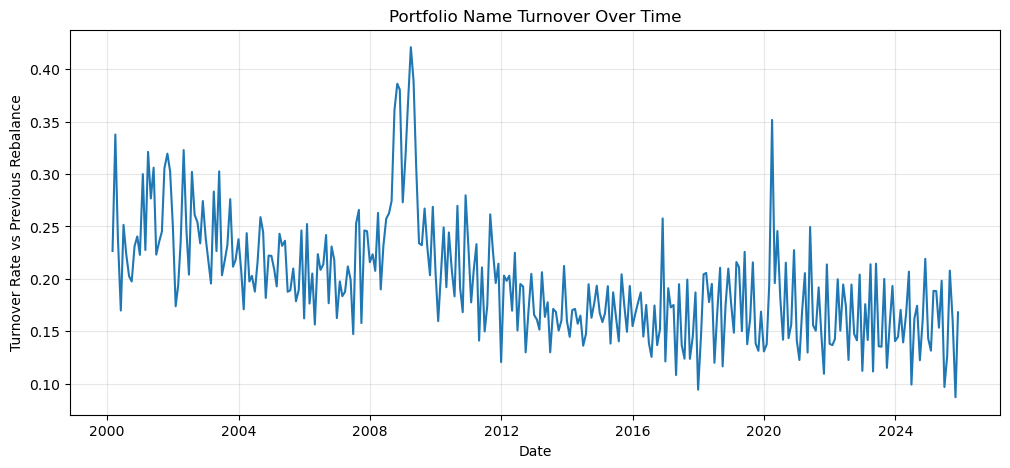

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_df["signal_date"], turnover_df["turnover_rate_vs_prev"])
plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
side_sets = (
    weights_at_E.groupby(["signal_date", "side"])["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
)

long_sets = (
    side_sets[side_sets["side"] == "long"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

short_sets = (
    side_sets[side_sets["side"] == "short"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

In [45]:
def compute_turnover_from_sets(df_sets: pd.DataFrame, label: str) -> pd.DataFrame:
    records = []
    for i in range(1, len(df_sets)):
        prev_set = df_sets.loc[i - 1, "ticker_set"]
        curr_set = df_sets.loc[i, "ticker_set"]
        prev_n = len(prev_set)
        union_n = len(curr_set | prev_set)

        records.append({
            "signal_date": df_sets.loc[i, "signal_date"],
            f"{label}_turnover": (len(curr_set - prev_set) + len(prev_set - curr_set)) / prev_n if prev_n > 0 else np.nan,
            f"{label}_jaccard": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
        })
    return pd.DataFrame(records)

long_turnover = compute_turnover_from_sets(long_sets, "long")
short_turnover = compute_turnover_from_sets(short_sets, "short")

long_turnover.head(), short_turnover.head()

(  signal_date  long_turnover  long_jaccard
 0  2000-02-29       0.246667      0.781065
 1  2000-03-31       0.324503      0.726257
 2  2000-04-28       0.297468      0.741758
 3  2000-05-31       0.201258      0.815029
 4  2000-06-30       0.245161      0.782857,
   signal_date  short_turnover  short_jaccard
 0  2000-02-29        0.220000       0.802395
 1  2000-03-31        0.350993       0.707182
 2  2000-04-28        0.183544       0.832370
 3  2000-05-31        0.150943       0.857988
 4  2000-06-30        0.258065       0.772727)

In [46]:
turnover_side = long_turnover.merge(short_turnover, on="signal_date", how="inner")
turnover_side.head()

,signal_date,long_turnover,long_jaccard,short_turnover,short_jaccard
0,2000-02-29,0.246667,0.781065,0.220000,0.802395
1,2000-03-31,0.324503,0.726257,0.350993,0.707182
2,2000-04-28,0.297468,0.741758,0.183544,0.832370
3,2000-05-31,0.201258,0.815029,0.150943,0.857988
4,2000-06-30,0.245161,0.782857,0.258065,0.772727


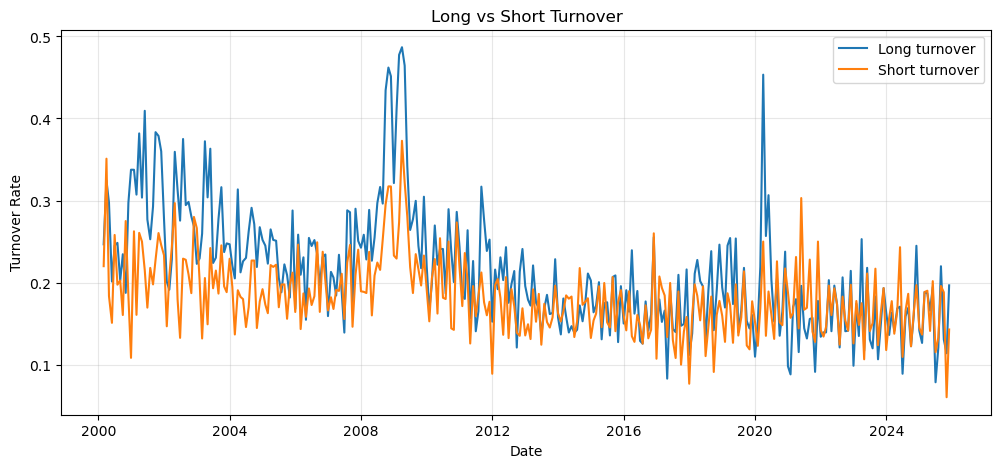

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_side["signal_date"], turnover_side["long_turnover"], label="Long turnover")
plt.plot(turnover_side["signal_date"], turnover_side["short_turnover"], label="Short turnover")
plt.title("Long vs Short Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [48]:
print("=== MODEL SUMMARY ===")
print(f"Net annualized Sharpe: {annualized_sharpe(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Long annualized Sharpe: {annualized_sharpe(ls_monthly['long_return']):.4f}")
print(f"Short annualized Sharpe: {annualized_sharpe(ls_monthly['short_return']):.4f}")
print(f"Long-short correlation: {ls_monthly['long_return'].corr(ls_monthly['short_return']):.4f}")
print(f"Max drawdown: {max_drawdown(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth['n_long'].mean():.2f}")
print(f"Average short breadth: {breadth['n_short'].mean():.2f}")

=== MODEL SUMMARY ===
Net annualized Sharpe: 0.5584
Long annualized Sharpe: 0.7559
Short annualized Sharpe: -0.3222
Long-short correlation: -0.7775
Max drawdown: -0.2614
Average universe size: 1858.07
Average long breadth: 371.07
Average short breadth: 371.21
